In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from scipy.ndimage import distance_transform_edt

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/drive-digital-retinal-images-for-vessel-extraction")

print("Path to dataset files:", path)

image_dir = f"{path}/DRIVE/training/images"
gt_dir    = f"{path}/DRIVE/training/1st_manual"
fov_dir   = f"{path}/DRIVE/training/mask"

img_files = sorted(os.listdir(image_dir))
gt_files  = sorted(os.listdir(gt_dir))
fov_files = sorted(os.listdir(fov_dir))

print(len(img_files), len(gt_files), len(fov_files))

Path to dataset files: /kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction
20 20 20


In [7]:
def sensitivity(pred, gt):
    tp = np.sum((pred==1) & (gt==1))
    fn = np.sum((pred==0) & (gt==1))
    return tp/(tp+fn)

def extract_thin_vessels(gt):
    thin_thr = 2 #Threshold for concluding thin or thick vessel, can be changed depending on what size of vessels we want to call thick and thin
    dist = distance_transform_edt(gt) #Checking distance from vessel to background, to determine thin or thick vessel
    thin = ((gt==1) & (dist<=thin_thr)).astype(np.uint8) #Converting to binary image
    return thin


windows = [15,25,35]
k_niblack = [-0.2,-0.1,0.1,0.2]
k_sauvola = [0.2,0.3,0.4]

In [8]:
best_niblack_score = 0
best_niblack_params = None

for w in windows:
    for k in k_niblack:
        scores = []
        for i in range(len(img_files)):
            img = cv2.imread(os.path.join(image_dir,img_files[i]))
            gt = cv2.imread(os.path.join(gt_dir,gt_files[i]),0)
            fov = cv2.imread(os.path.join(fov_dir,fov_files[i]),0) #Loading gt and fov as grayscale images
            
            img_g = img[:,:,1] #Using only green channel due to its higher vessel-to-background contrast (from web searches, AI suggestions)
            gt = (gt>0).astype(np.uint8)
            fov = (fov>0).astype(np.uint8) 
           
            thr = threshold_niblack(img_g, window_size=w, k=k)
            pred = (img_g<thr).astype(np.uint8) #Predicted binary mask
            #Again, for this specific application, if a pixel has value less than threshold, it gets classified as foreground, unlike the usual logic, since vessels are darker
            pred *= fov
            gt *= fov #To erase all predictions that are out of the retina, limiting ourselves to the retina field, according to given fov
           
            scores.append(sensitivity(pred, extract_thin_vessels(gt)))
        mean_score = np.mean(scores)
        if mean_score > best_niblack_score:
            best_niblack_score = mean_score
            best_niblack_params = (w,k)

print("Best Niblack Params: ", best_niblack_params)
print("Best Niblack Sensitivity: ", best_niblack_score)

Best Niblack Params:  (25, -0.2)
Best Niblack Sensitivity:  0.8792600854965151


In [9]:
#Following the same procedure, same reasonings, for sauvola thresholding
best_sauvola_score = 0
best_sauvola_params = None

for w in windows:
    for k in k_sauvola:
        scores = []
        for i in range(len(img_files)):
            img = cv2.imread(os.path.join(image_dir,img_files[i]))
            gt  = cv2.imread(os.path.join(gt_dir,gt_files[i]),0)
            fov = cv2.imread(os.path.join(fov_dir,fov_files[i]),0)
            
            img_g = img[:,:,1]
            gt = (gt>0).astype(np.uint8)
            fov = (fov>0).astype(np.uint8)
            
            thr = threshold_sauvola(img_g, window_size=w, k=k)
            pred = (img_g < thr).astype(np.uint8)
            pred *= fov
            gt *= fov
            
            scores.append(sensitivity(pred, extract_thin_vessels(gt)))
        
        mean_score = np.mean(scores)
        if mean_score > best_sauvola_score:
            best_sauvola_score = mean_score
            best_sauvola_params = (w,k)

print("Best Sauvola Params: ", best_sauvola_params)
print("Best Sauvola Sensitivity: ", best_sauvola_score)

Best Sauvola Params:  (35, 0.2)
Best Sauvola Sensitivity:  0.11932047007892399


In [11]:
print("Finally, we have: ")
print("Sensitivity with Niblack thresholding:",best_niblack_score)
print("Sensitivity with Sauvola thresholding:",best_sauvola_score)

Finally, we have: 
Sensitivity with Niblack thresholding: 0.8792600854965151
Sensitivity with Sauvola thresholding: 0.11932047007892399


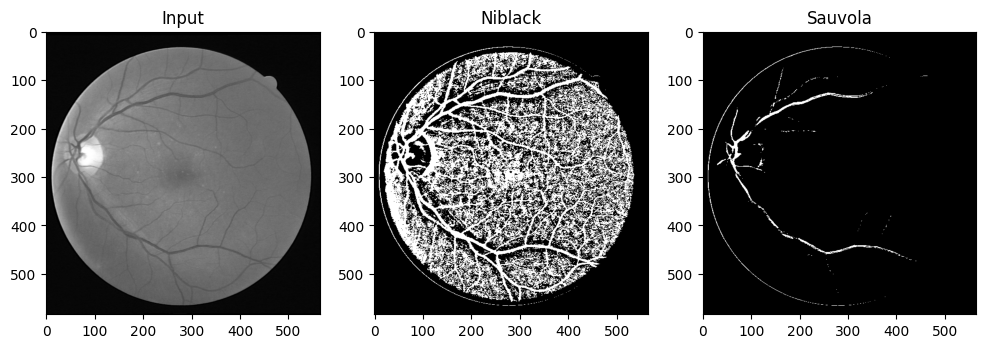

In [12]:
img = cv2.imread(os.path.join(image_dir,img_files[0]))
gt = cv2.imread(os.path.join(gt_dir,gt_files[0]),0)
fov = cv2.imread(os.path.join(fov_dir,fov_files[0]),0)

img_g = img[:,:,1]
gt = (gt>0).astype(np.uint8)
fov = (fov>0).astype(np.uint8)

thr_n = threshold_niblack(img_g, window_size=best_niblack_params[0], k=best_niblack_params[1])
thr_s = threshold_sauvola(img_g, window_size=best_sauvola_params[0], k=best_sauvola_params[1])

nb = (img_g<thr_n).astype(np.uint8)*fov
sv = (img_g<thr_s).astype(np.uint8)*fov

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_g,cmap='gray')
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(nb,cmap='gray')
plt.title("Niblack")

plt.subplot(1,3,3)
plt.imshow(sv,cmap='gray')
plt.title("Sauvola")

plt.show()


Sauvola and Niblack behaved significantly differently for this application. Sauvola was very conservative in identifying vessels, while Niblack was lenient. As a result, Niblack produced extremely high false positives, whereas Sauvola exhibited higher false negatives, leading to significantly higher sensitivity for Niblack. In this application, foreground pixels satisfy pixel<T, meaning darker pixels are classified as foreground, which mean vessels. 

**Niblack behaviour**

Niblack computes the threshold as T=m+k*s with negative k, which shifts the threshold slightly below the local mean. Although lowering the threshold makes the condition seemingly stricter, in vessel neighborhoods the local mean decreases due to dark vessel intensities and the standard deviation increases slightly. The threshold therefore follows this shift and remains above most vessel pixels while staying close enough to the background mean that small texture variations are also included, explaining the aggressive segmentation and high false positives. To simplify, Niblack is very sensitive and reacts to even minor variations.

**Sauvola behaviour**

On the other hand, Sauvola computes T=m(1+k(s/R−1)), normalizing the standard deviation. Because thin vessels typically produce only small local variance changes, the normalization limits how much the threshold shifts. Many weak thin structures therefore fail to satisfy the foreground condition, resulting in lower true positives, and thus, the reduced sensitivity. Basically, Sauvola reacts only if the variance is large enough, which is the case in scenarios involving both, the bright background, and also the low intensity thick vessels.

Thus, despite both being local adaptive thresholding techniques, their different handling of variance leads to markedly different behavior: Niblack favors sensitivity at the cost of noise, whereas Sauvola favors robustness at the expense of thin-vessel recall.